In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

2026-04-25 03:48:39.400183: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777088919.779987      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777088919.886248      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777088920.833256      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777088920.833302      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777088920.833305      55 computation_placer.cc:177] computation placer alr

In [4]:
base_dir = "/kaggle/input/datasets/insyirahazman/menstrual-blood-color/data_256_256"

In [5]:
rows = []
for label in sorted(os.listdir(base_dir)):
    class_dir = os.path.join(base_dir, label)
    if not os.path.isdir(class_dir):
        continue
    for fname in sorted(os.listdir(class_dir)):
        if fname.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.webp')):
            rows.append({'filepath': os.path.join(class_dir, fname), 'label': label})
df = pd.DataFrame(rows)
print(df.head())

                                            filepath  label
0  /kaggle/input/datasets/insyirahazman/menstrual...  Black
1  /kaggle/input/datasets/insyirahazman/menstrual...  Black
2  /kaggle/input/datasets/insyirahazman/menstrual...  Black
3  /kaggle/input/datasets/insyirahazman/menstrual...  Black
4  /kaggle/input/datasets/insyirahazman/menstrual...  Black


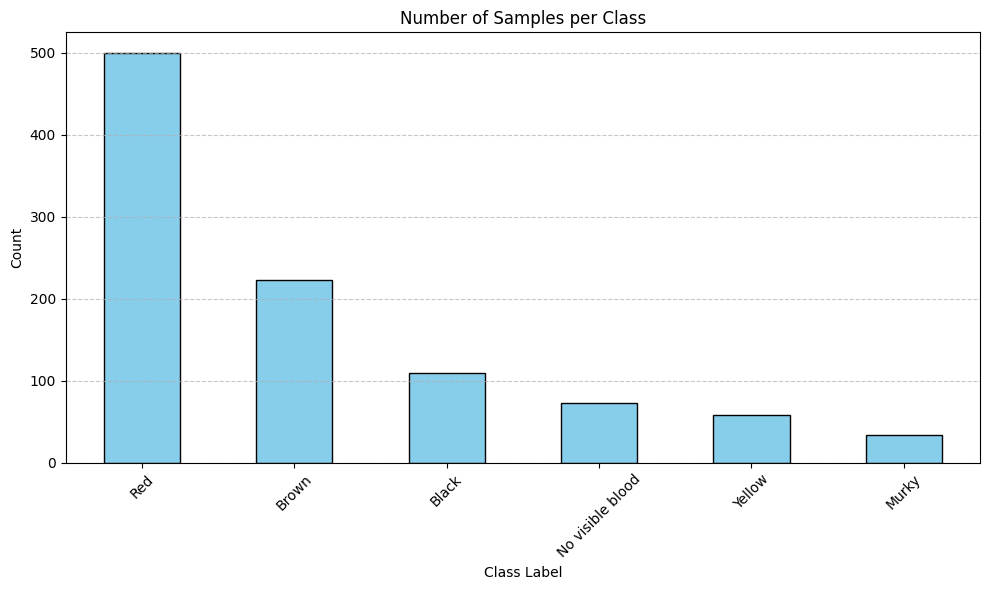

In [6]:
class_counts = df['label'].value_counts()
plt.figure(figsize=(10, 6))
class_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Number of Samples per Class')
plt.xlabel('Class Label')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Pre-Processing

In [7]:
print("Loading images...")
images = []
labels = []
for i, row in df.iterrows():
    try:
        img = load_img(row["filepath"], target_size=(256, 256))
        img_array = img_to_array(img) / 255.0  # normalize
        images.append(img_array)
        labels.append(row["label"])
        
        if (i + 1) % 100 == 0:
            print(f"Loaded {i + 1} images.")
    except Exception as e:
        print(f"Error loading {row['filepath']}: {e}")

Loading images...
Loaded 100 images.
Loaded 200 images.
Loaded 300 images.
Loaded 400 images.
Loaded 500 images.
Loaded 600 images.
Loaded 700 images.
Loaded 800 images.
Loaded 900 images.


In [8]:
images = np.array(images)
labels = np.array(labels)
print(f"Images shape: {images.shape}, Labels shape: {labels.shape}")

Images shape: (997, 256, 256, 3), Labels shape: (997,)


In [9]:
# Encode labels
le = LabelEncoder()
labels_int = le.fit_transform(labels)
labels_onehot = to_categorical(labels_int)

print("Integer labels (first 5):", labels_int[:5])
print("One-hot labels (first 5):", labels_onehot[:5])
print("Classes:", le.classes_)

num_classes = len(le.classes_)
print(f"Number of classes: {num_classes}")

Integer labels (first 5): [0 0 0 0 0]
One-hot labels (first 5): [[1. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0.]]
Classes: ['Black' 'Brown' 'Murky' 'No visible blood' 'Red' 'Yellow']
Number of classes: 6


## Split

In [10]:
# First split: 80% train+val, 20% test
X_temp, X_test, y_temp, y_test, labels_temp, labels_test = train_test_split(
    images, labels_onehot, labels_int, 
    test_size=0.2, random_state=42, stratify=labels_int
)

In [11]:
X_train, X_val, y_train, y_val, labels_train, labels_val = train_test_split(
    X_temp, y_temp, labels_temp,
    test_size=0.25, random_state=42, stratify=labels_temp  
)

In [12]:
print(f"Train set: {X_train.shape}, {y_train.shape}")
print(f"Validation set: {X_val.shape}, {y_val.shape}")
print(f"Test set: {X_test.shape}, {y_test.shape}")

Train set: (597, 256, 256, 3), (597, 6)
Validation set: (200, 256, 256, 3), (200, 6)
Test set: (200, 256, 256, 3), (200, 6)


## Model

In [13]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.resnet50 import preprocess_input

In [14]:
# classifier head for all models
def create_classifier_head(base_model, num_classes):
    model = tf.keras.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.BatchNormalization(),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

In [15]:
def create_vgg_model(input_shape, num_classes):
    """Load pretrained InceptionV3 but make it fully trainable"""
    base_model = InceptionV3(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )
    base_model.trainable = True
    return create_classifier_head(base_model, num_classes)

In [16]:
model = create_vgg_model((256, 256, 3), num_classes)
model_name = "InceptionV3"

model.compile(
    optimizer=Adam(learning_rate=0.0001),  # lower learning rate since using pretrained weights
    loss='categorical_crossentropy',  
    metrics=['accuracy']
)

model.summary()

I0000 00:00:1777088994.168953      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777088994.171986      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)       │ (None, 6, 6, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_94          │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,992,934 (87.71 MB)

 Trainable params: 22,954,406 (87.56 MB)

 Non-trainable params: 38,528 (150.50 KB)

In [17]:
# Callbacks
model_path = '/kaggle/working/inceptionv3_baseline.h5'
checkpoint = ModelCheckpoint(
    model_path,
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    mode='max',
    verbose=1,
    restore_best_weights=True
)

In [18]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=16,
    callbacks=[checkpoint, early_stopping],
    verbose=1
)

Epoch 1/30


I0000 00:00:1777089037.089569     126 service.cc:152] XLA service 0x7b1be40bbff0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777089037.089606     126 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777089037.089609     126 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777089044.435911     126 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-25 03:50:55.960912: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-25 03:50:56.107227: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-25 03:50:56.848117: E external/local_xl

37/38 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.4158 - loss: 1.9530

2026-04-25 03:51:42.617015: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-25 03:51:42.760785: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-25 03:51:43.396031: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-25 03:51:43.696512: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4177 - loss: 1.9459   
Epoch 1: val_accuracy improved from -inf to 0.54500, saving model to /kaggle/working/inceptionv3_baseline.h5


...

38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 212ms/step - accuracy: 0.7257 - loss: 0.7883 - val_accuracy: 0.6650 - val_loss: 0.9478
Epoch 4/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.7960 - loss: 0.5827
Epoch 4: val_accuracy improved from 0.66500 to 0.70500, saving model to /kaggle/working/inceptionv3_baseline.h5


38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 213ms/step - accuracy: 0.7963 - loss: 0.5817 - val_accuracy: 0.7050 - val_loss: 0.8962
Epoch 5/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.8669 - loss: 0.3847
Epoch 5: val_accuracy improved from 0.70500 to 0.74500, saving model to /kaggle/working/inceptionv3_baseline.h5


38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 214ms/step - accuracy: 0.8667 - loss: 0.3852 - val_accuracy: 0.7450 - val_loss: 0.6908
Epoch 6/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.9065 - loss: 0.2868
Epoch 6: val_accuracy improved from 0.74500 to 0.77000, saving model to /kaggle/working/inceptionv3_baseline.h5


38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 215ms/step - accuracy: 0.9063 - loss: 0.2868 - val_accuracy: 0.7700 - val_loss: 0.7584
Epoch 7/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.8723 - loss: 0.2937
Epoch 7: val_accuracy improved from 0.77000 to 0.80000, saving model to /kaggle/working/inceptionv3_baseline.h5


38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 215ms/step - accuracy: 0.8728 - loss: 0.2932 - val_accuracy: 0.8000 - val_loss: 0.7055
Epoch 8/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.9251 - loss: 0.2290
Epoch 8: val_accuracy did not improve from 0.80000
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 177ms/step - accuracy: 0.9251 - loss: 0.2291 - val_accuracy: 0.7800 - val_loss: 0.6497
Epoch 9/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.9421 - loss: 0.1644
Epoch 9: val_accuracy did not improve from 0.80000
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 178ms/step - accuracy: 0.9421 - loss: 0.1649 - val_accuracy: 0.7700 - val_loss: 0.6830
Epoch 10/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.9684 - loss: 0.1360
Epoch 10: val_accuracy did not improve from 0.80000
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 178ms/step - accuracy: 0.9679 - loss: 0.1372 - val_accuracy: 0.7500 - val_loss: 0.7604
Epoch 11/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.9250 - loss: 0.1766
Epoch 11: val_accuracy did not i

In [19]:
loss, accuracy = model.evaluate(X_train, y_train)
print(f"Train Accuracy: {accuracy*100:.2f}%")

19/19 ━━━━━━━━━━━━━━━━━━━━ 17s 476ms/step - accuracy: 0.9953 - loss: 0.0998
Train Accuracy: 98.99%


In [20]:
val_loss, val_acc = model.evaluate(X_val, y_val)
print(f"Validation Accuracy: {val_acc*100:.2f}%")

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.7986 - loss: 0.7357
Validation Accuracy: 80.00%


## Loss and Accuracy Matrices

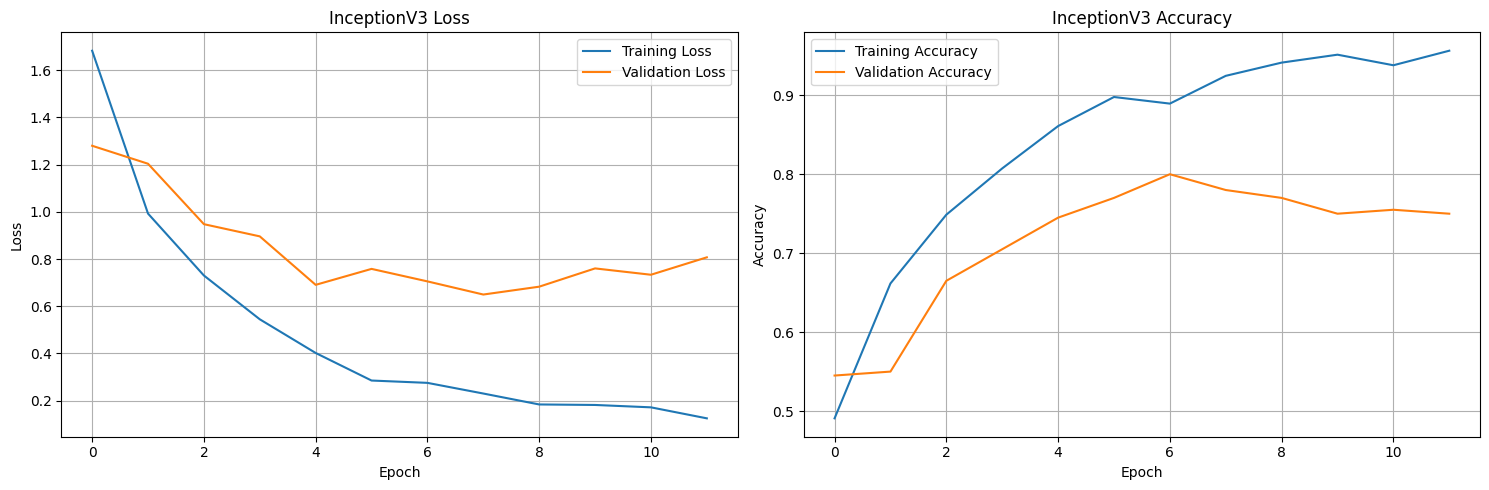

In [21]:
# Plot training history
plt.figure(figsize=(15, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('InceptionV3 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('InceptionV3 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Other Matrices

In [23]:
# Load the best model
best_model = tf.keras.models.load_model(model_path)

In [24]:
train_preds = np.argmax(best_model.predict(X_train, batch_size=16), axis=1)
val_preds = np.argmax(best_model.predict(X_val, batch_size=16), axis=1)
test_preds = np.argmax(best_model.predict(X_test, batch_size=16), axis=1)

38/38 ━━━━━━━━━━━━━━━━━━━━ 15s 231ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 399ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step


In [25]:
y_train_int = np.argmax(y_train, axis=1)
y_val_int = np.argmax(y_val, axis=1)
y_test_int = np.argmax(y_test, axis=1)

In [26]:
train_accuracy = np.mean(y_train_int == train_preds)
val_accuracy = np.mean(y_val_int == val_preds)
test_accuracy = np.mean(y_test_int == test_preds)

print(f"\nFinal Results using Pretrained {model_name} with Focal Loss:")
print(f"Train Accuracy: {train_accuracy:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


Final Results using Pretrained InceptionV3 with Focal Loss:
Train Accuracy: 0.9899
Validation Accuracy: 0.8000
Test Accuracy: 0.7450


In [27]:
# Detailed classification report for test set
print("\n=== Train Set Classification Report ===")
print(classification_report(y_train_int, train_preds, target_names=le.classes_))


=== Train Set Classification Report ===
                  precision    recall  f1-score   support

           Black       1.00      0.97      0.98        65
           Brown       0.99      1.00      1.00       133
           Murky       1.00      0.95      0.97        20
No visible blood       0.96      0.98      0.97        44
             Red       0.99      1.00      1.00       300
          Yellow       0.97      0.97      0.97        35

        accuracy                           0.99       597
       macro avg       0.99      0.98      0.98       597
    weighted avg       0.99      0.99      0.99       597



In [28]:
# Detailed classification report for test set
print("\n=== Validation Set Classification Report ===")
print(classification_report(y_val_int, val_preds, target_names=le.classes_))


=== Validation Set Classification Report ===
                  precision    recall  f1-score   support

           Black       0.90      0.41      0.56        22
           Brown       0.85      0.89      0.87        45
           Murky       0.40      0.29      0.33         7
No visible blood       0.75      0.64      0.69        14
             Red       0.81      0.96      0.88       100
          Yellow       0.50      0.33      0.40        12

        accuracy                           0.80       200
       macro avg       0.70      0.59      0.62       200
    weighted avg       0.79      0.80      0.78       200



In [29]:
# Detailed classification report for test set
print("\n=== Test Set Classification Report ===")
print(classification_report(y_test_int, test_preds, target_names=le.classes_))


=== Test Set Classification Report ===
                  precision    recall  f1-score   support

           Black       0.38      0.23      0.29        22
           Brown       0.89      0.71      0.79        45
           Murky       0.33      0.14      0.20         7
No visible blood       0.87      0.87      0.87        15
             Red       0.77      0.92      0.84       100
          Yellow       0.46      0.55      0.50        11

        accuracy                           0.74       200
       macro avg       0.62      0.57      0.58       200
    weighted avg       0.73      0.74      0.73       200



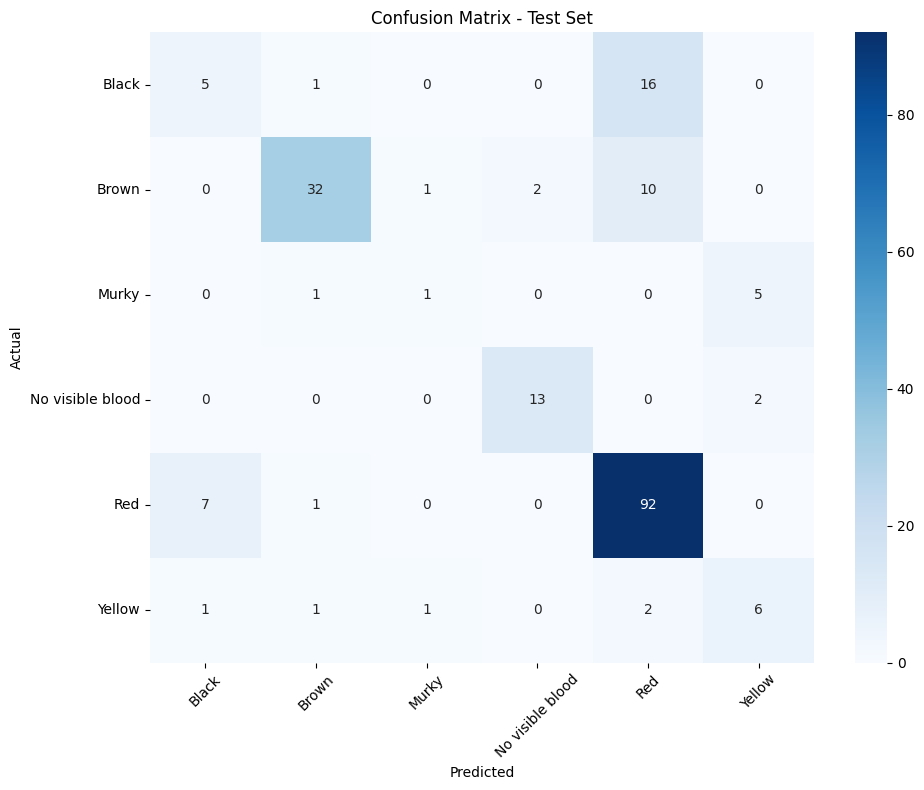

In [30]:
# Confusion Matrix for test set
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test_int, test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - Test Set')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()